# Plotting Notebook (auto from artifacts)

This notebook loads the **latest** run exported by your analysis notebook and produces figures.
It is **name-agnostic**: it uses the `meta` attached to the artifacts (when available) to
find all summary tables and the "everything" table. It falls back to simple heuristics if
those keys are missing.


## Workflow

1. In the analysis notebook, run the export cell (right before any plotting) to write Parquet tables
   and a `meta.json` into a timestamped folder under `artifacts/`.
2. Open this notebook and run the cells top-to-bottom to generate figures from the latest run.
3. Figures are saved under `plots/<run_id>/` so every run remains reproducible.


In [1]:
# Load artifacts and resolve summary + everything tables
import os
import pandas as pd
from artifacts_io import load_artifacts
import seaborn as sns

tables, meta, run_dir = load_artifacts(out_dir="artifacts")
run_id = os.path.basename(run_dir)
print("Loaded run:", run_dir)
print("Meta:", meta)

# Resolve keys from meta if present; otherwise infer
summary_keys = meta.get("summary_keys", [])
everything_key = meta.get("everything_key")

if not summary_keys:
    # Heuristic: names containing common summary tokens
    name_hits = ("summary", "sum_", "_sum", "agg", "group", "pivot", "tbl", "by_", "_by")
    summary_keys = [k for k in tables if any(tok in k.lower() for tok in name_hits)]

if everything_key is None:
    # Largest table by rows as the 'everything' table
    everything_key = max(tables, key=lambda k: tables[k].shape[0])

print("\nResolved table keys:")
print("  summary_keys :", summary_keys if summary_keys else "(none)")
print("  everything_key:", everything_key)

# Preview heads
for k in tables:
    print(f"\nTable: {k}  shape={tables[k].shape}")
    display(tables[k].head(5))


Loaded run: artifacts\run_20250820_141313
Meta: {'created': '2025-08-20 14:13:13', 'n_tables': 5, 'notes': 'Summaries + full analysis table exported for plotting/other notebooks', 'source_notebook': 'working_datacrunch.ipynb', 'summary_keys': ['df_summary', 'summary_by_type', 'summary_by_year', 'summary_by_decade'], 'everything_key': 'df'}

Resolved table keys:
  summary_keys : ['df_summary', 'summary_by_type', 'summary_by_year', 'summary_by_decade']
  everything_key: df

Table: df  shape=(63713, 27)


,id,page_number,inferred_latitude,inferred_longitude,actual_latitude,actual_longitude,location,townships_ranges_sections,watersource_name,actual_county,...,latitude,longitude,water_type_clean,water_type_review,year_start,year_end,years_list,date_parse_status,date_parse_notes,needs_date_review
0,70038399,445,,,39.13472,-120.94833,"NEASE sec.22, T.15 N., R.9 E.","['T.15 N., R.9 E., SEC. 22']",Rollins Reservoir,Placer County,...,39.134720,-120.948330,Reservoir,None,1964,1966,"[1964, 1966]",EXACT_RANGE,None,False
1,553,177,,,35.933333,-118.483333,"NE sec. 14 T. 23 S., R. 32 E., 3 miles upstrea...","['T. 23 S., R. 32 E., NE sec. 14']",Kern River near Kernville,Tehama County,...,35.933333,-118.483333,Stream discharge,None,1912,1942,"[1912, 1942]",EXACT_RANGE,None,False
2,455,159,,,,,"Near La Grange, California",['3S 14E NE 1/4 sec. 3'],TUOLUMNE RIVER ABOVE LA GRANGE DAM,Tuolumne County,...,NaN,NaN,Stream discharge,None,1929,1930,"[1929, 1930]",EXACT_RANGE,None,False
3,251,43,,,32.81666667,-114.5,"Near Yuma, Arizona","['T. 15 S., R. 23 E.', 'SE1 sec. 10, T. 16 S.,...",Yuma Main Canal,Imperial County,...,32.816667,-114.500000,Stream discharge,None,1910,1938,"[1910, 1938]",EXACT_RANGE,None,False
4,2850,45,38.5,-122.0,,,Coyote Valley,,Putah Creek,,...,38.500000,-122.000000,Stream discharge,None,<NA>,<NA>,None,UNPARSED,None,True



Table: df_summary  shape=(63081, 28)


,id,page_number,inferred_latitude,inferred_longitude,actual_latitude,actual_longitude,location,townships_ranges_sections,watersource_name,actual_county,...,longitude,water_type_clean,water_type_review,year_start,year_end,years_list,date_parse_status,date_parse_notes,needs_date_review,decade
0,70038399,445,,,39.13472,-120.94833,"NEASE sec.22, T.15 N., R.9 E.","['T.15 N., R.9 E., SEC. 22']",Rollins Reservoir,Placer County,...,-120.948330,Reservoir,None,1964,1966,"[1964, 1966]",EXACT_RANGE,None,False,1960
1,553,177,,,35.933333,-118.483333,"NE sec. 14 T. 23 S., R. 32 E., 3 miles upstrea...","['T. 23 S., R. 32 E., NE sec. 14']",Kern River near Kernville,Tehama County,...,-118.483333,Stream discharge,None,1912,1942,"[1912, 1942]",EXACT_RANGE,None,False,1910
2,455,159,,,,,"Near La Grange, California",['3S 14E NE 1/4 sec. 3'],TUOLUMNE RIVER ABOVE LA GRANGE DAM,Tuolumne County,...,NaN,Stream discharge,None,1929,1930,"[1929, 1930]",EXACT_RANGE,None,False,1920
3,251,43,,,32.81666667,-114.5,"Near Yuma, Arizona","['T. 15 S., R. 23 E.', 'SE1 sec. 10, T. 16 S.,...",Yuma Main Canal,Imperial County,...,-114.500000,Stream discharge,None,1910,1938,"[1910, 1938]",EXACT_RANGE,None,False,1910
4,2850,45,38.5,-122.0,,,Coyote Valley,,Putah Creek,,...,-122.000000,Stream discharge,None,<NA>,<NA>,None,UNPARSED,None,True,<NA>



Table: summary_by_decade  shape=(102, 5)


,water_type_clean,decade,n_rows,n_pages,n_docs
0,Groundwater,1850,1,1,1
1,Groundwater,1860,5,3,2
2,Groundwater,1870,53,44,10
3,Groundwater,1880,174,93,12
4,Groundwater,1890,244,90,17



Table: summary_by_type  shape=(9, 4)


,water_type_clean,n_rows,n_pages,n_docs
0,Groundwater,11575,3118,325
1,Irrigation,1408,832,214
2,Not water related,392,210,135
3,Other,6,3,2
4,Precipitation,483,191,95



Table: summary_by_year  shape=(685, 5)


,water_type_clean,year_start,n_rows,n_pages,n_docs
0,Groundwater,1856,1,1,1
1,Groundwater,1863,1,1,1
2,Groundwater,1868,3,2,1
3,Groundwater,1869,1,1,1
4,Groundwater,1870,4,4,3


## Prep for mapping

In [2]:
# ==== Build combined coordinates from df_summary (actual > inferred) ====
import re
import numpy as np
import pandas as pd

# 0) Select the df_summary table from artifacts
if "tables" not in globals():
    raise RuntimeError("Run the artifacts loading cell first.")

if "df_summary" in tables:
    df_summary = tables["df_summary"].copy()
else:
    # case-insensitive match if key differs in case
    match_keys = [k for k in tables if k.lower() == "df_summary"]
    if not match_keys:
        raise KeyError("I can't find a table named 'df_summary' in artifacts.")
    df_summary = tables[match_keys[0]].copy()

print("df_summary shape:", df_summary.shape)

# ---------- Optional: set explicit column names here if you already know them ----------
# If you know the exact names, set them (strings) and this will override auto-detection below.
EXPLICIT_LAT_ACTUAL = None   # e.g., "Latitude_actual"
EXPLICIT_LAT_INFER  = None   # e.g., "Latitude_inferred"
EXPLICIT_LON_ACTUAL = None   # e.g., "Longitude_actual"
EXPLICIT_LON_INFER  = None   # e.g., "Longitude_inferred"
# -----------------------------------------------------------------------

def _coerce_num(s):
    return pd.to_numeric(s, errors="coerce")

def _first_nonnull(series_list, index):
    if not series_list:
        return pd.Series(index=index, dtype="float64")
    stacked = pd.concat([_coerce_num(s) for s in series_list], axis=1)
    return stacked.bfill(axis=1).iloc[:, 0]

def _find_cols(df, lat_or_lon, which):
    """
    lat_or_lon: 'lat' or 'lon'
    which: 'actual' or 'inferred'
    """
    pat_lat = r'(?:\blat\b|latitude)'
    pat_lon = r'(?:\blon\b|\blong\b|longitude)'
    pat_kind = r'actual' if which == "actual" else r'infer|inferred|estimat|approx'
    cols = []
    for c in df.columns:
        cl = c.lower()
        if (re.search(pat_lat, cl) if lat_or_lon=='lat' else re.search(pat_lon, cl)) and re.search(pat_kind, cl):
            cols.append(c)
    return cols

def _fallback_cols(df, lat_or_lon):
    pat = r'(?:\blat\b|latitude)' if lat_or_lon=='lat' else r'(?:\blon\b|\blong\b|longitude)'
    return [c for c in df.columns if re.search(pat, c.lower())]

# 1) Gather candidate columns (prefer explicit names if provided)
lat_actual_cols = [EXPLICIT_LAT_ACTUAL] if (EXPLICIT_LAT_ACTUAL and EXPLICIT_LAT_ACTUAL in df_summary.columns) else _find_cols(df_summary, 'lat','actual')
lat_infer_cols  = [EXPLICIT_LAT_INFER]  if (EXPLICIT_LAT_INFER  and EXPLICIT_LAT_INFER  in df_summary.columns) else _find_cols(df_summary, 'lat','inferred')
lon_actual_cols = [EXPLICIT_LON_ACTUAL] if (EXPLICIT_LON_ACTUAL and EXPLICIT_LON_ACTUAL in df_summary.columns) else _find_cols(df_summary, 'lon','actual')
lon_infer_cols  = [EXPLICIT_LON_INFER]  if (EXPLICIT_LON_INFER  and EXPLICIT_LON_INFER  in df_summary.columns) else _find_cols(df_summary, 'lon','inferred')

# Fallbacks if column names don’t contain 'actual'/'inferred'
if not (lat_actual_cols or lat_infer_cols):
    lat_infer_cols = _fallback_cols(df_summary, 'lat')
if not (lon_actual_cols or lon_infer_cols):
    lon_infer_cols = _fallback_cols(df_summary, 'lon')

lat_names_order = lat_actual_cols + lat_infer_cols
lon_names_order = lon_actual_cols + lon_infer_cols

lat_sources = [df_summary[c] for c in lat_names_order if c in df_summary.columns]
lon_sources = [df_summary[c] for c in lon_names_order if c in df_summary.columns]

if not lat_sources or not lon_sources:
    raise ValueError("Couldn’t find latitude/longitude columns. If you know them, set the EXPLICIT_* names above.")

# 2) Build combined columns (actual → inferred)
df_summary["lat_combined"] = _first_nonnull(lat_sources, df_summary.index)
df_summary["lon_combined"] = _first_nonnull(lon_sources, df_summary.index)

# 3) Normalize longitudes and fix obvious lat/lon swaps
def _normalize_lon(x):
    # bring into [-180, 180]
    return ((x + 180) % 360) - 180

if (df_summary["lon_combined"] > 180).mean() > 0.2:
    df_summary["lon_combined"] = _normalize_lon(df_summary["lon_combined"])

swap_mask = (~df_summary["lat_combined"].between(-90, 90)) & (df_summary["lon_combined"].between(-90, 90))
if swap_mask.any():
    df_summary.loc[swap_mask, ["lat_combined","lon_combined"]] = (
        df_summary.loc[swap_mask, ["lon_combined","lat_combined"]].to_numpy()
    )

# 4) Record which source column was used (NaN-safe)
def _first_used_name(series_list, names):
    out = np.full(len(df_summary), np.nan, dtype=object)
    for s, n in zip(series_list, names):
        take = pd.isna(out) & ~_coerce_num(s).isna()
        out[take.values] = n
    return pd.Series(out, index=df_summary.index)

df_summary["lat_source_col"] = _first_used_name([df_summary[c] for c in lat_names_order], lat_names_order) if lat_names_order else np.nan
df_summary["lon_source_col"] = _first_used_name([df_summary[c] for c in lon_names_order], lon_names_order) if lon_names_order else np.nan

def _safe_tag(val):
    if not isinstance(val, str):
        return "unspecified"
    v = val.lower()
    if "actual" in v:
        return "actual"
    if "infer" in v or "estimat" in v or "approx" in v:
        return "inferred"
    return "unspecified"

df_summary["coord_source"] = [
    _safe_tag(la) if _safe_tag(la) == _safe_tag(lo) else f"{_safe_tag(la)}/{_safe_tag(lo)}"
    for la, lo in zip(df_summary["lat_source_col"], df_summary["lon_source_col"])
]

# 5) Drop invalid coordinates
valid = df_summary["lat_combined"].between(-90, 90) & df_summary["lon_combined"].between(-180, 180)
dropped = (~valid).sum()
df_summary = df_summary.loc[valid].copy()

print(f"Combined coordinates built. Dropped {dropped} rows with invalid/missing coords.")
print("coord_source breakdown:")
print(df_summary["coord_source"].value_counts(dropna=False))
print("Preview:")
display(df_summary[[
    *(lat_names_order[:1] or []), *(lon_names_order[:1] or []),
    "lat_combined","lon_combined","coord_source"
]].head(10))



df_summary shape: (63081, 28)
Combined coordinates built. Dropped 4173 rows with invalid/missing coords.
coord_source breakdown:
coord_source
actual             34044
inferred           24857
actual/inferred        6
inferred/actual        1
Name: count, dtype: int64
Preview:


,actual_latitude,actual_longitude,lat_combined,lon_combined,coord_source
0,39.13472,-120.94833,39.134720,-120.948330,actual
1,35.933333,-118.483333,35.933333,-118.483333,actual
3,32.81666667,-114.5,32.816667,-114.500000,actual
4,,,38.500000,-122.000000,inferred
5,,,38.500000,-122.000000,inferred
6,,,38.500000,-122.000000,inferred
7,,,38.500000,-122.000000,inferred
8,,,38.696900,-121.767200,inferred
9,36.216111,-118.871667,36.216111,-118.871667,actual
10,,,35.333300,-118.516700,inferred


## Plotting maps 

Saved: plots\run_20250820_141313\all_sites_us_static_ALL.png


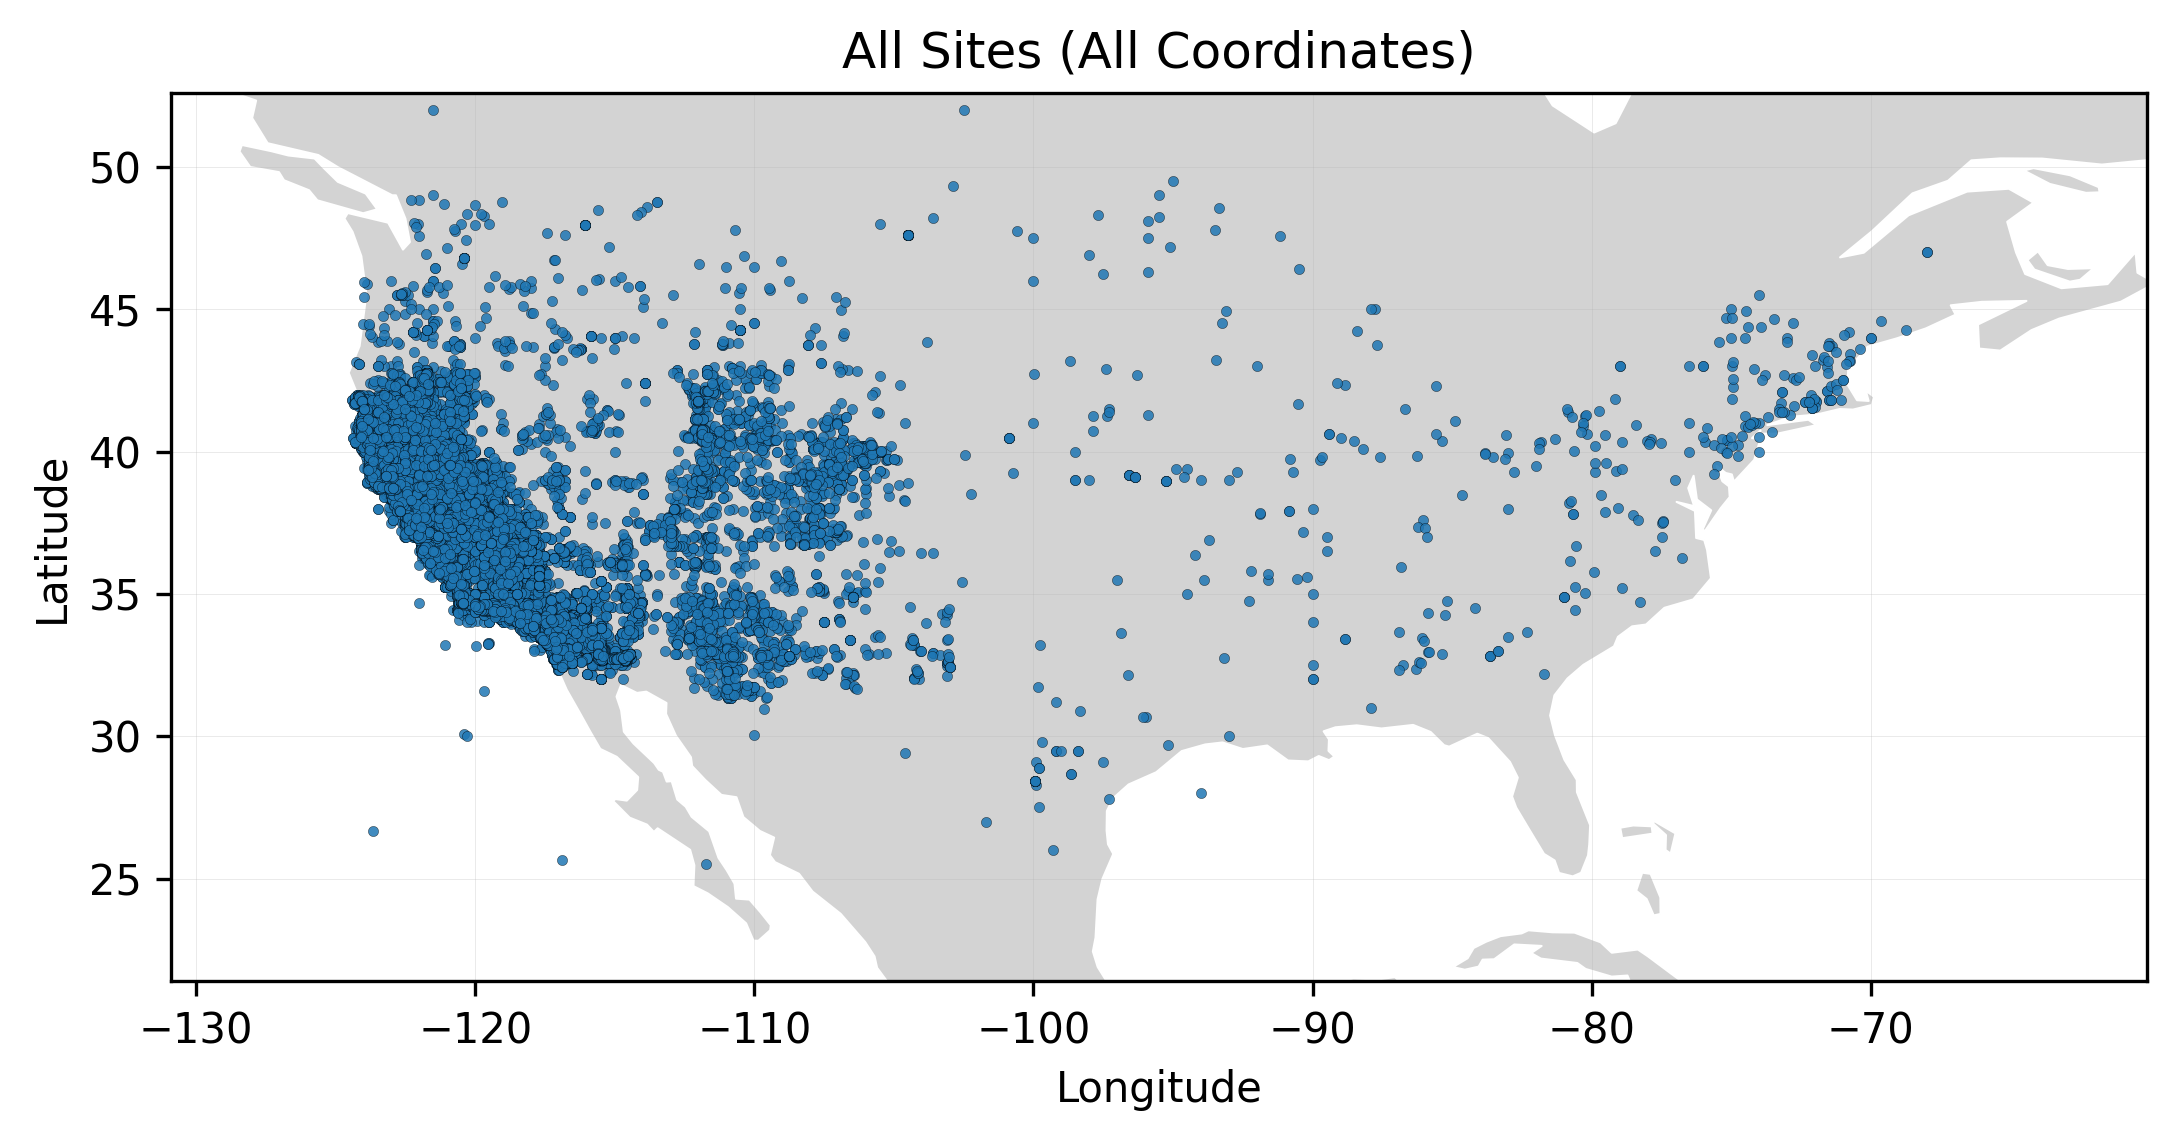

Saved: plots\run_20250820_141313\all_sites_us_static_ACTUAL_vs_INFERRED.png


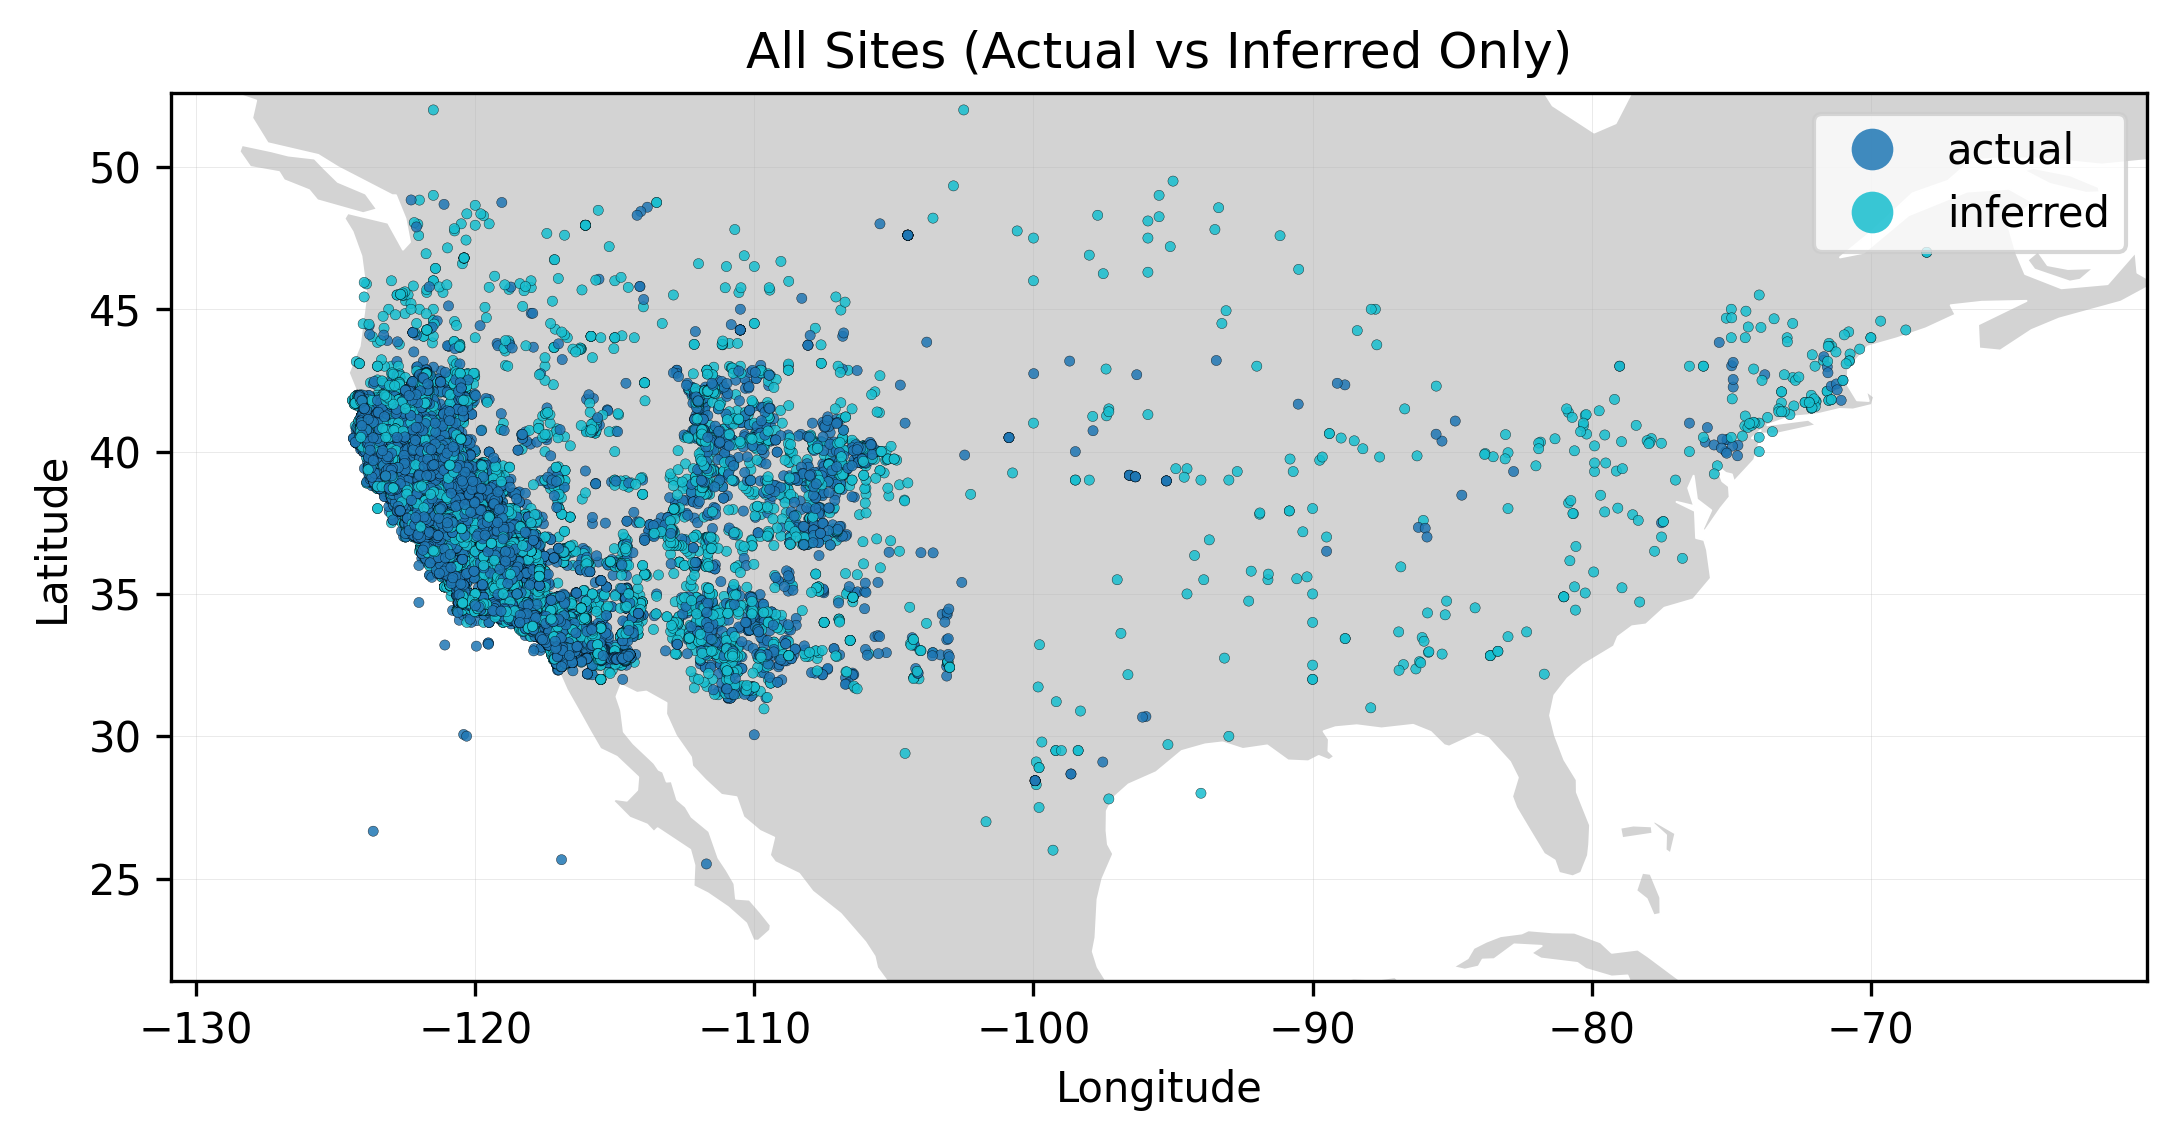

In [4]:
# ==== Static maps (no clipped points) with state outlines via geodatasets ====
import os
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

# deps
try:
    import geodatasets
except Exception as e:
    raise RuntimeError("geodatasets is required. In a notebook cell, run:\n\n  %pip install geodatasets\n") from e

# 1) GeoDataFrame from df_summary (WGS84)
gdf = gpd.GeoDataFrame(
    df_summary,
    geometry=gpd.points_from_xy(df_summary["lon_combined"], df_summary["lat_combined"]),
    crs="EPSG:4326"
)

# 2) Data-driven bounds with generous padding so no points get cut off
minx, miny, maxx, maxy = gdf.total_bounds

# Clamp to CONUS just in case
conus_bounds = (-125.0, 24.0, -66.0, 50.0)
minx = max(minx, conus_bounds[0]); miny = max(miny, conus_bounds[1])
maxx = min(maxx, conus_bounds[2]); maxy = min(maxy, conus_bounds[3])

# Add 10% padding (min 1°) to ensure full marker visibility at edges
pad_lon = max(1.0, (maxx - minx) * 0.10)
pad_lat = max(1.0, (maxy - miny) * 0.10)
xmin, ymin, xmax, ymax = (minx - pad_lon, miny - pad_lat, maxx + pad_lon, maxy + pad_lat)

# Fallback if extent degenerates (e.g., very tight or single-point)
if not np.isfinite([xmin, ymin, xmax, ymax]).all() or (xmax - xmin) < 1 or (ymax - ymin) < 1:
    xmin, ymin, xmax, ymax = (-126, 31, -113, 43)  # CA + neighbors

# 3) Context layers (Natural Earth via geodatasets)
land = gpd.read_file(geodatasets.get_path("naturalearth.land")).to_crs("EPSG:4326")

# State/province outlines (try several keys; versions vary)
state_keys = [
    "naturalearth.cultural.admin_1_states_provinces_lines",
    "naturalearth.cultural.ne_10m_admin_1_states_provinces_lines",
    "naturalearth.cultural.ne_50m_admin_1_states_provinces_lines",
    "naturalearth.cultural.admin_1_states_provinces",  # polygons; we'll draw boundaries
]
states = None
for key in state_keys:
    try:
        states = gpd.read_file(geodatasets.get_path(key)).to_crs("EPSG:4326")
        break
    except Exception:
        continue

# Clip context layers to our padded bbox
land_region = land.cx[xmin:xmax, ymin:ymax]
states_region = states.cx[xmin:xmax, ymin:ymax] if states is not None else None

# 4) Output folder
outdir = os.path.join("plots", run_id)
os.makedirs(outdir, exist_ok=True)

# ---------- MAP A: All points (single style) ----------
fig, ax = plt.subplots(figsize=(8.5, 6.5), dpi=300)

# Land
land_region.plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.5, zorder=0)

# States
if states_region is not None:
    try:
        states_region.boundary.plot(ax=ax, color="white", linewidth=0.6, zorder=1)
        states_region.boundary.plot(ax=ax, color="black", linewidth=0.3, zorder=2)
    except Exception:
        states_region.plot(ax=ax, color="none", edgecolor="black", linewidth=0.4, zorder=2)

# All points (no grouping)
gdf.plot(
    ax=ax,
    color="C0",
    markersize=6,
    alpha=0.85,
    edgecolor="k",
    linewidth=0.1,
    zorder=3,
)

# Apply padded limits (prevents cutoffs)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title("All Sites (All Coordinates)", fontsize=12)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.grid(True, linewidth=0.2, alpha=0.3)

outfile_A = os.path.join(outdir, "all_sites_us_static_ALL.png")
plt.savefig(outfile_A, dpi=300, bbox_inches="tight")
print("Saved:", outfile_A)
plt.show()

# ---------- MAP B: Only actual vs inferred (drop mixed rows) ----------
mask_ai = gdf["coord_source"].isin(["actual", "inferred"])
gdf_ai = gdf.loc[mask_ai].copy()

fig, ax = plt.subplots(figsize=(8.5, 6.5), dpi=300)

land_region.plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.5, zorder=0)
if states_region is not None:
    try:
        states_region.boundary.plot(ax=ax, color="white", linewidth=0.6, zorder=1)
        states_region.boundary.plot(ax=ax, color="black", linewidth=0.3, zorder=2)
    except Exception:
        states_region.plot(ax=ax, color="none", edgecolor="black", linewidth=0.4, zorder=2)

# Plot by coord_source (actual vs inferred only)
gdf_ai.plot(
    ax=ax,
    column="coord_source",
    categorical=True,
    legend=True,
    markersize=6,
    alpha=0.85,
    edgecolor="k",
    linewidth=0.1,
    zorder=3,
)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title("All Sites (Actual vs Inferred Only)", fontsize=12)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.grid(True, linewidth=0.2, alpha=0.3)

outfile_B = os.path.join(outdir, "all_sites_us_static_ACTUAL_vs_INFERRED.png")
plt.savefig(outfile_B, dpi=300, bbox_inches="tight")
print("Saved:", outfile_B)
plt.show()


## Flag and filter rows outside of CA

In [6]:
# ==== Flag rows outside California; robust with fallback to CA bounding box ====
import os
import geopandas as gpd
import numpy as np

# Build GeoDataFrame
gdf = gpd.GeoDataFrame(
    df_summary,
    geometry=gpd.points_from_xy(df_summary["lon_combined"], df_summary["lat_combined"]),
    crs="EPSG:4326"
)

# Try Natural Earth states first
ca_geom = None
try:
    import geodatasets
    state_keys = [
        "naturalearth.cultural.admin_1_states_provinces",                  # polygons
        "naturalearth.cultural.ne_10m_admin_1_states_provinces",           # polygons
        "naturalearth.cultural.admin_1_states_provinces_lines",            # lines (we'll buffer)
        "naturalearth.cultural.ne_10m_admin_1_states_provinces_lines",     # lines (we'll buffer)
        "naturalearth.cultural.ne_50m_admin_1_states_provinces_lines",
    ]
    states = None
    for key in state_keys:
        try:
            states = gpd.read_file(geodatasets.get_path(key)).to_crs("EPSG:4326")
            break
        except Exception:
            continue
    if states is not None:
        # If we loaded a line layer, turn it into a thin polygon via buffer
        if states.geom_type.iloc[0].lower().endswith("line"):
            # small buffer (~0.05 deg) to create a polygon surface
            states = states.buffer(0.05)
            states = gpd.GeoDataFrame(geometry=states, crs="EPSG:4326")
            states["name"] = np.nan  # no names available on some line layers

        # Try common name fields for California
        name_col = None
        for cand in ["name", "name_en", "name_long", "adm1name", "region"]:
            if cand in states.columns:
                name_col = cand
                break
        if name_col is not None:
            ca = states[states[name_col].astype(str).str.contains("California", case=False, na=False)]
        else:
            ca = gpd.GeoDataFrame(columns=states.columns, geometry=[], crs=states.crs)

        if not ca.empty:
            ca_geom = ca.unary_union
except Exception:
    pass  # we'll fall back below

# Fallback: tight California bounding box (state extremes; includes offshore, but good for QA)
from shapely.geometry import box
if ca_geom is None:
    # California geographic extremes (approx):
    # West/East: -124.48 to -114.13 ; South/North: 32.45 to 42.01
    ca_geom = box(-124.48, 32.45, -114.13, 42.01)

# Compute in/out
within_ca = gdf.within(ca_geom)
gdf["in_california"] = within_ca

outside_ca = gdf.loc[~within_ca].copy()

print(f"Total rows: {len(gdf):,}")
print(f"Inside California: {int(within_ca.sum()):,}")
print(f"Outside California: {len(outside_ca):,}")

# Preview a few suspicious rows
preview_cols = [c for c in ["site","site_id","name","station","coord_source","lat_combined","lon_combined"] if c in gdf.columns]
display(outside_ca.head(20)[preview_cols] if preview_cols else outside_ca.head(20))

# Export for review in the original data file
outdir = os.path.join("plots", run_id)
os.makedirs(outdir, exist_ok=True)
out_csv = os.path.join(outdir, "sites_outside_CA.csv")
outside_ca.drop(columns="geometry").to_csv(out_csv, index=False)
print("Exported rows outside California to:", out_csv)


Total rows: 58,908
Inside California: 54,376
Outside California: 4,532


,coord_source,lat_combined,lon_combined
29,inferred,41.150000,-111.970000
37,actual,31.746100,-110.566900
50,actual,42.150000,-121.700000
51,actual,42.133300,-121.966700
67,actual,42.233333,-120.500000
76,actual,42.500000,-111.316667
78,inferred,33.147800,-111.732100
100,actual,34.366700,-111.783300
107,actual,38.041667,-111.450000
108,actual,38.001389,-111.389444


Exported rows outside California to: plots\run_20250820_141313\sites_outside_CA.csv


## CA only plots

Total rows: 58,908 | California-only: 52,610
Saved: plots\run_20250820_141313\CA_ONLY_all_sites_static_ALL.png


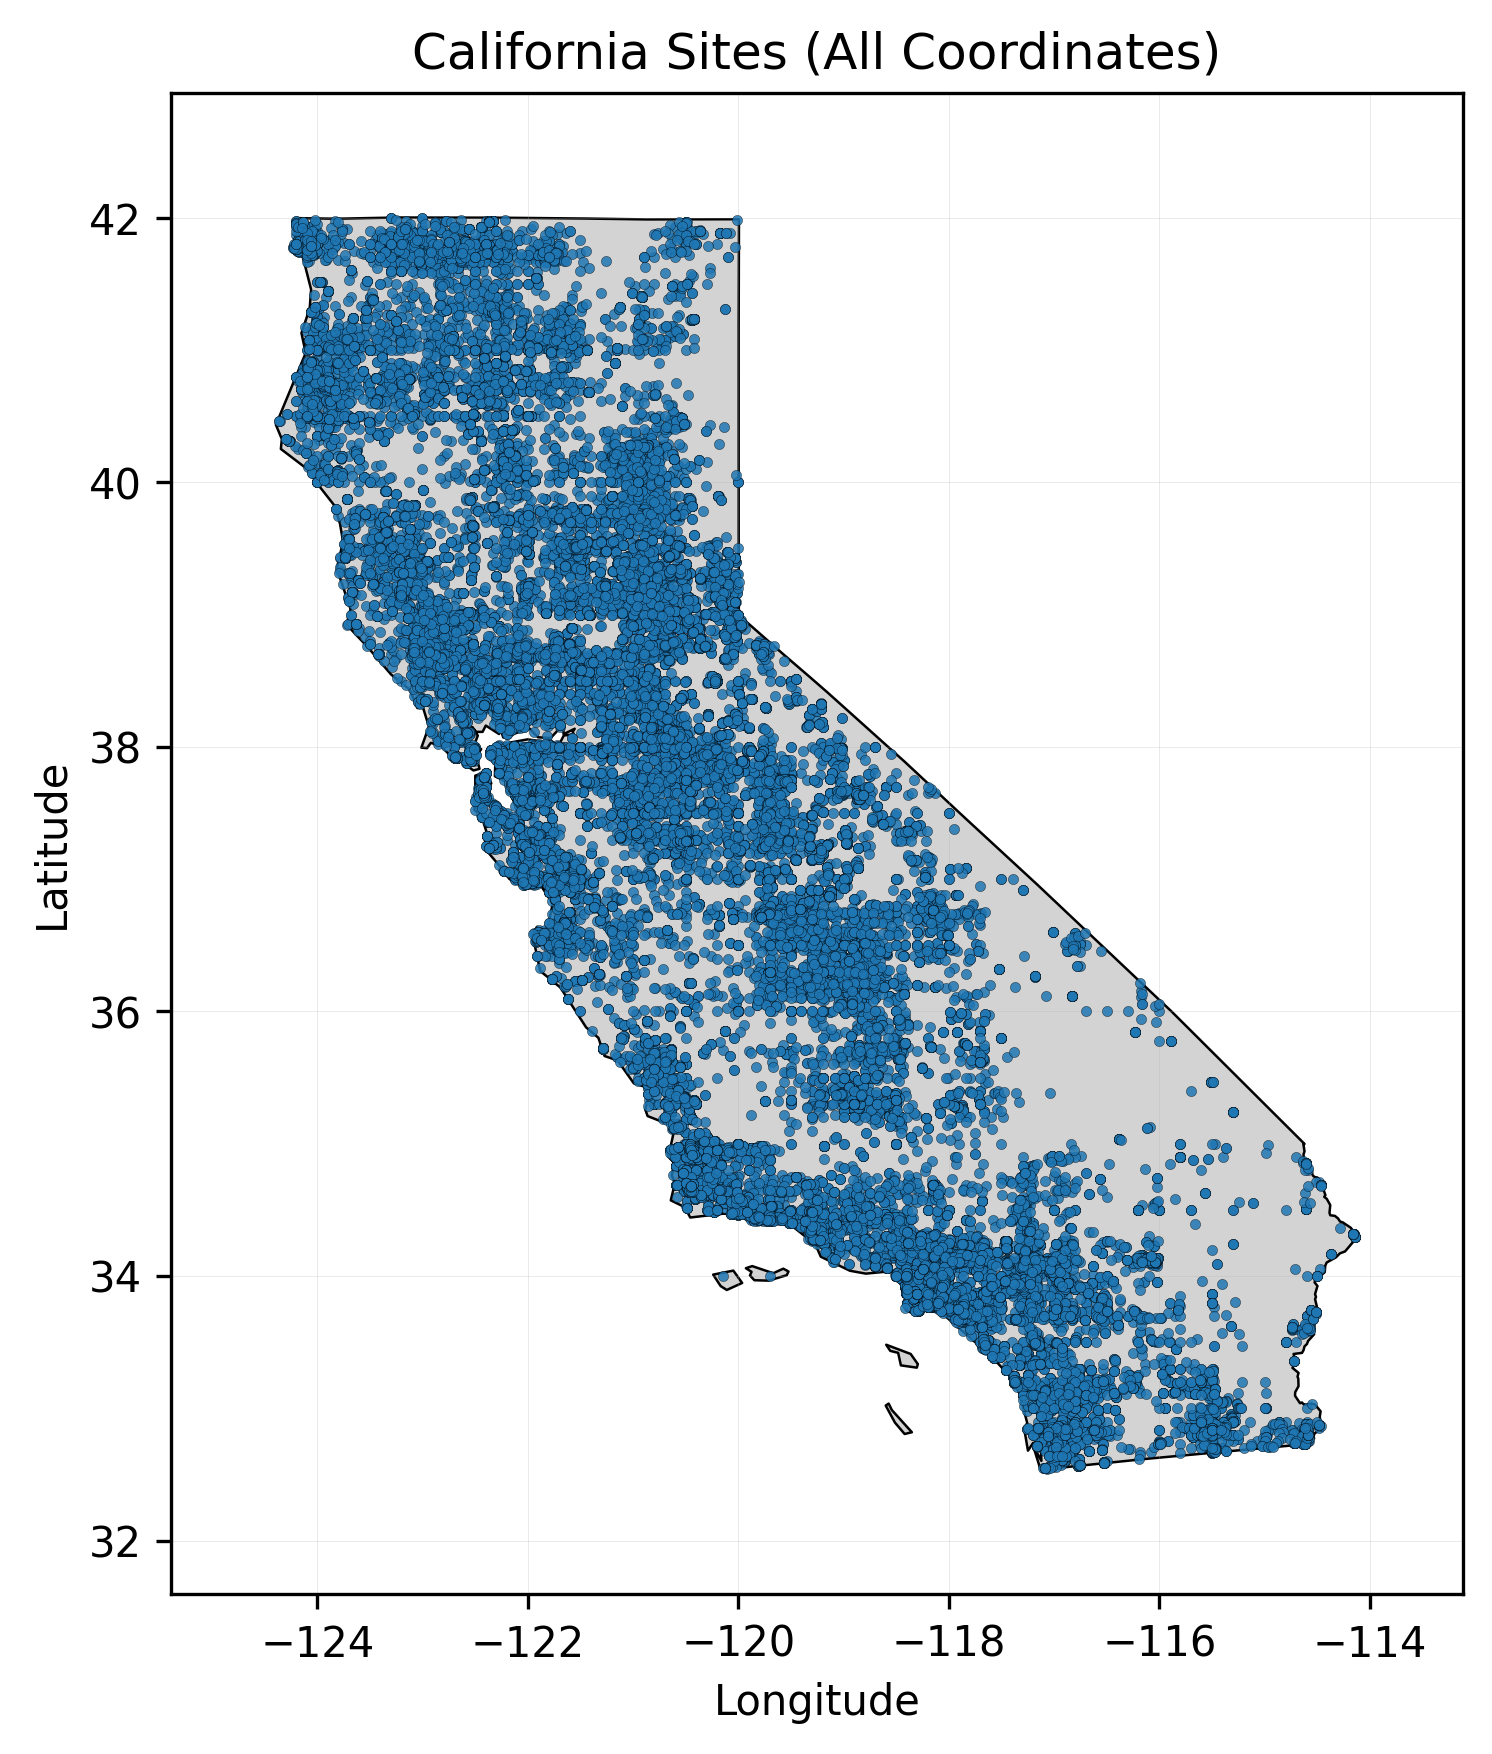

Saved: plots\run_20250820_141313\CA_ONLY_all_sites_static_ACTUAL_vs_INFERRED.png


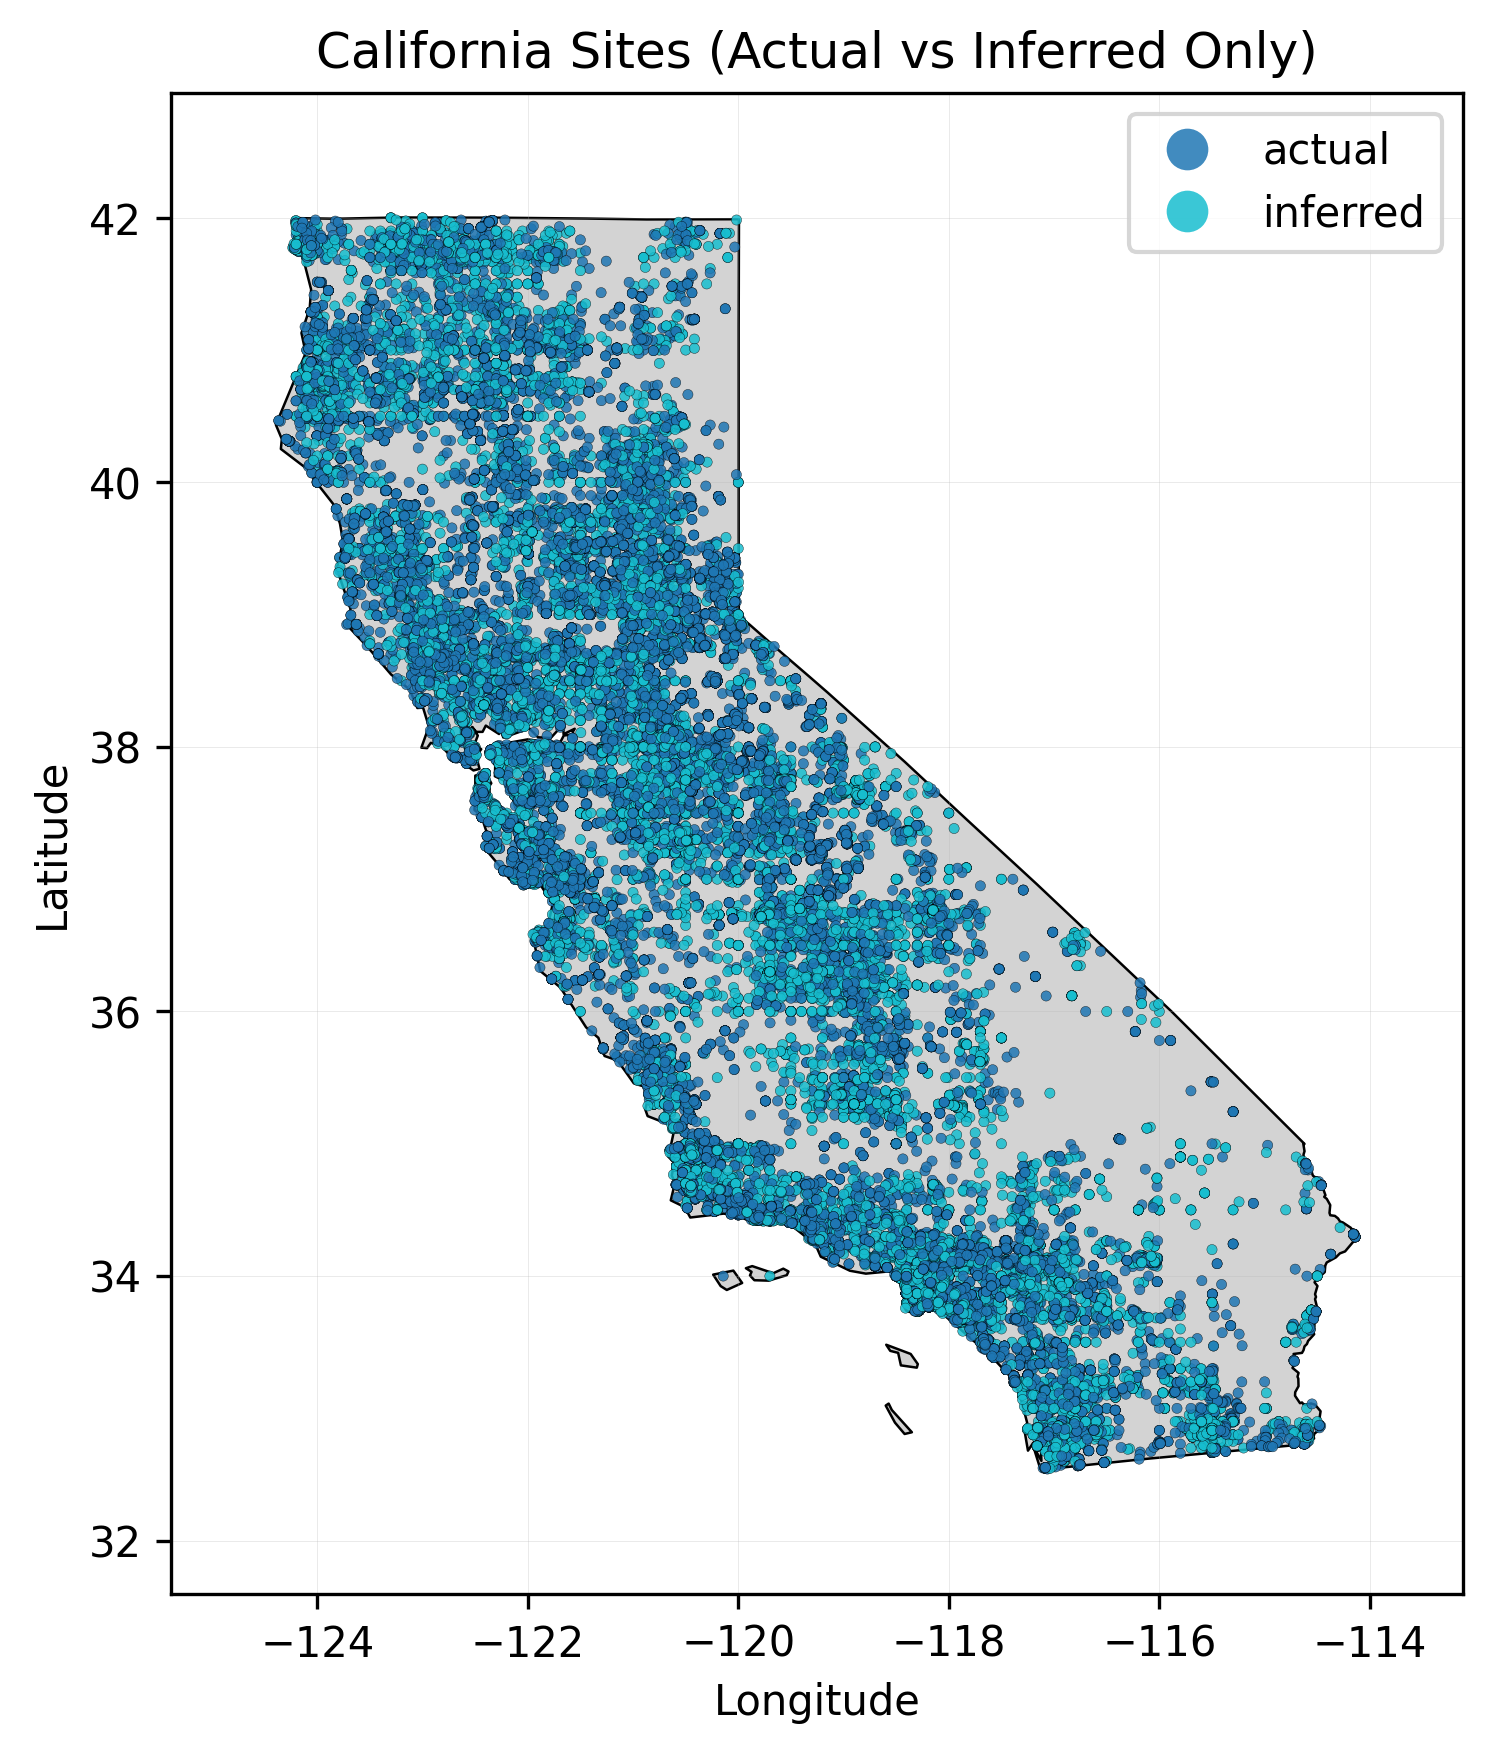

In [9]:
# ==== California-only maps using your ca_poly.shp shapefile ====
import os
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import box

# 0) Path to your shapefile
path_to_ca = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\ca_shapefile\ca_poly.shp"

# 1) Load CA polygon; ensure valid geometry and CRS = EPSG:4326
ca = gpd.read_file(path_to_ca)
if ca.empty:
    raise RuntimeError(f"No features found in {path_to_ca}")

if hasattr(ca, "is_valid") and not ca.is_valid.all():
    ca = ca.buffer(0)
    ca = gpd.GeoDataFrame(geometry=ca, crs=gpd.read_file(path_to_ca).crs)

# Reproject to WGS84 lat/lon if needed
if ca.crs is None:
    raise RuntimeError("California shapefile has no CRS defined. Please check the .prj file.")
if ca.crs.to_string().upper() not in ("EPSG:4326", "WGS84"):
    ca = ca.to_crs("EPSG:4326")

# Dissolve to a single polygon (Shapely 2.x safe)
ca_poly = ca.union_all() if hasattr(ca, "union_all") else ca.unary_union

# 2) Build GeoDataFrame of points
gdf = gpd.GeoDataFrame(
    df_summary,
    geometry=gpd.points_from_xy(df_summary["lon_combined"], df_summary["lat_combined"]),
    crs="EPSG:4326"
)

# 3) Filter to California
in_ca = gdf.within(ca_poly)
gdf_ca = gdf.loc[in_ca].copy()
print(f"Total rows: {len(gdf):,} | California-only: {len(gdf_ca):,}")

if len(gdf_ca) == 0:
    raise RuntimeError("No points fall inside California based on your shapefile.")

# 4) Data-driven extent with generous padding
minx, miny, maxx, maxy = gdf_ca.total_bounds
pad_lon = max(0.5, (maxx - minx) * 0.10)
pad_lat = max(0.5, (maxy - miny) * 0.10)
xmin, ymin, xmax, ymax = (minx - pad_lon, miny - pad_lat, maxx + pad_lon, maxy + pad_lat)

# 5) Output folder
outdir = os.path.join("plots", run_id)
os.makedirs(outdir, exist_ok=True)

# ---------- MAP A: All CA points ----------
fig, ax = plt.subplots(figsize=(8.5, 6.5), dpi=300)

gpd.GeoSeries([ca_poly], crs="EPSG:4326").plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.6, zorder=0)

gdf_ca.plot(
    ax=ax,
    color="C0",
    markersize=6,
    alpha=0.85,
    edgecolor="k",
    linewidth=0.1,
    zorder=2,
)

ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_title("California Sites (All Coordinates)", fontsize=12)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.grid(True, linewidth=0.2, alpha=0.3)

outfile_A = os.path.join(outdir, "CA_ONLY_all_sites_static_ALL.png")
plt.savefig(outfile_A, dpi=300, bbox_inches="tight")
print("Saved:", outfile_A)
plt.show()

# ---------- MAP B: CA only — Actual vs Inferred ----------
mask_ai = gdf_ca["coord_source"].isin(["actual", "inferred"])
gdf_ca_ai = gdf_ca.loc[mask_ai].copy()

fig, ax = plt.subplots(figsize=(8.5, 6.5), dpi=300)

gpd.GeoSeries([ca_poly], crs="EPSG:4326").plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.6, zorder=0)

gdf_ca_ai.plot(
    ax=ax,
    column="coord_source",
    categorical=True,
    legend=True,
    markersize=6,
    alpha=0.85,
    edgecolor="k",
    linewidth=0.1,
    zorder=2,
)

ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_title("California Sites (Actual vs Inferred Only)", fontsize=12)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.grid(True, linewidth=0.2, alpha=0.3)

outfile_B = os.path.join(outdir, "CA_ONLY_all_sites_static_ACTUAL_vs_INFERRED.png")
plt.savefig(outfile_B, dpi=300, bbox_inches="tight")
print("Saved:", outfile_B)
plt.show()


## By water category 

Categories retained: ['Reservoir' 'Stream discharge' 'Groundwater' 'Precipitation'
 'Water quality' 'Springs' 'Irrigation']
Saved: plots\run_20250820_141313\CA_ONLY_by_water_type_filtered.png


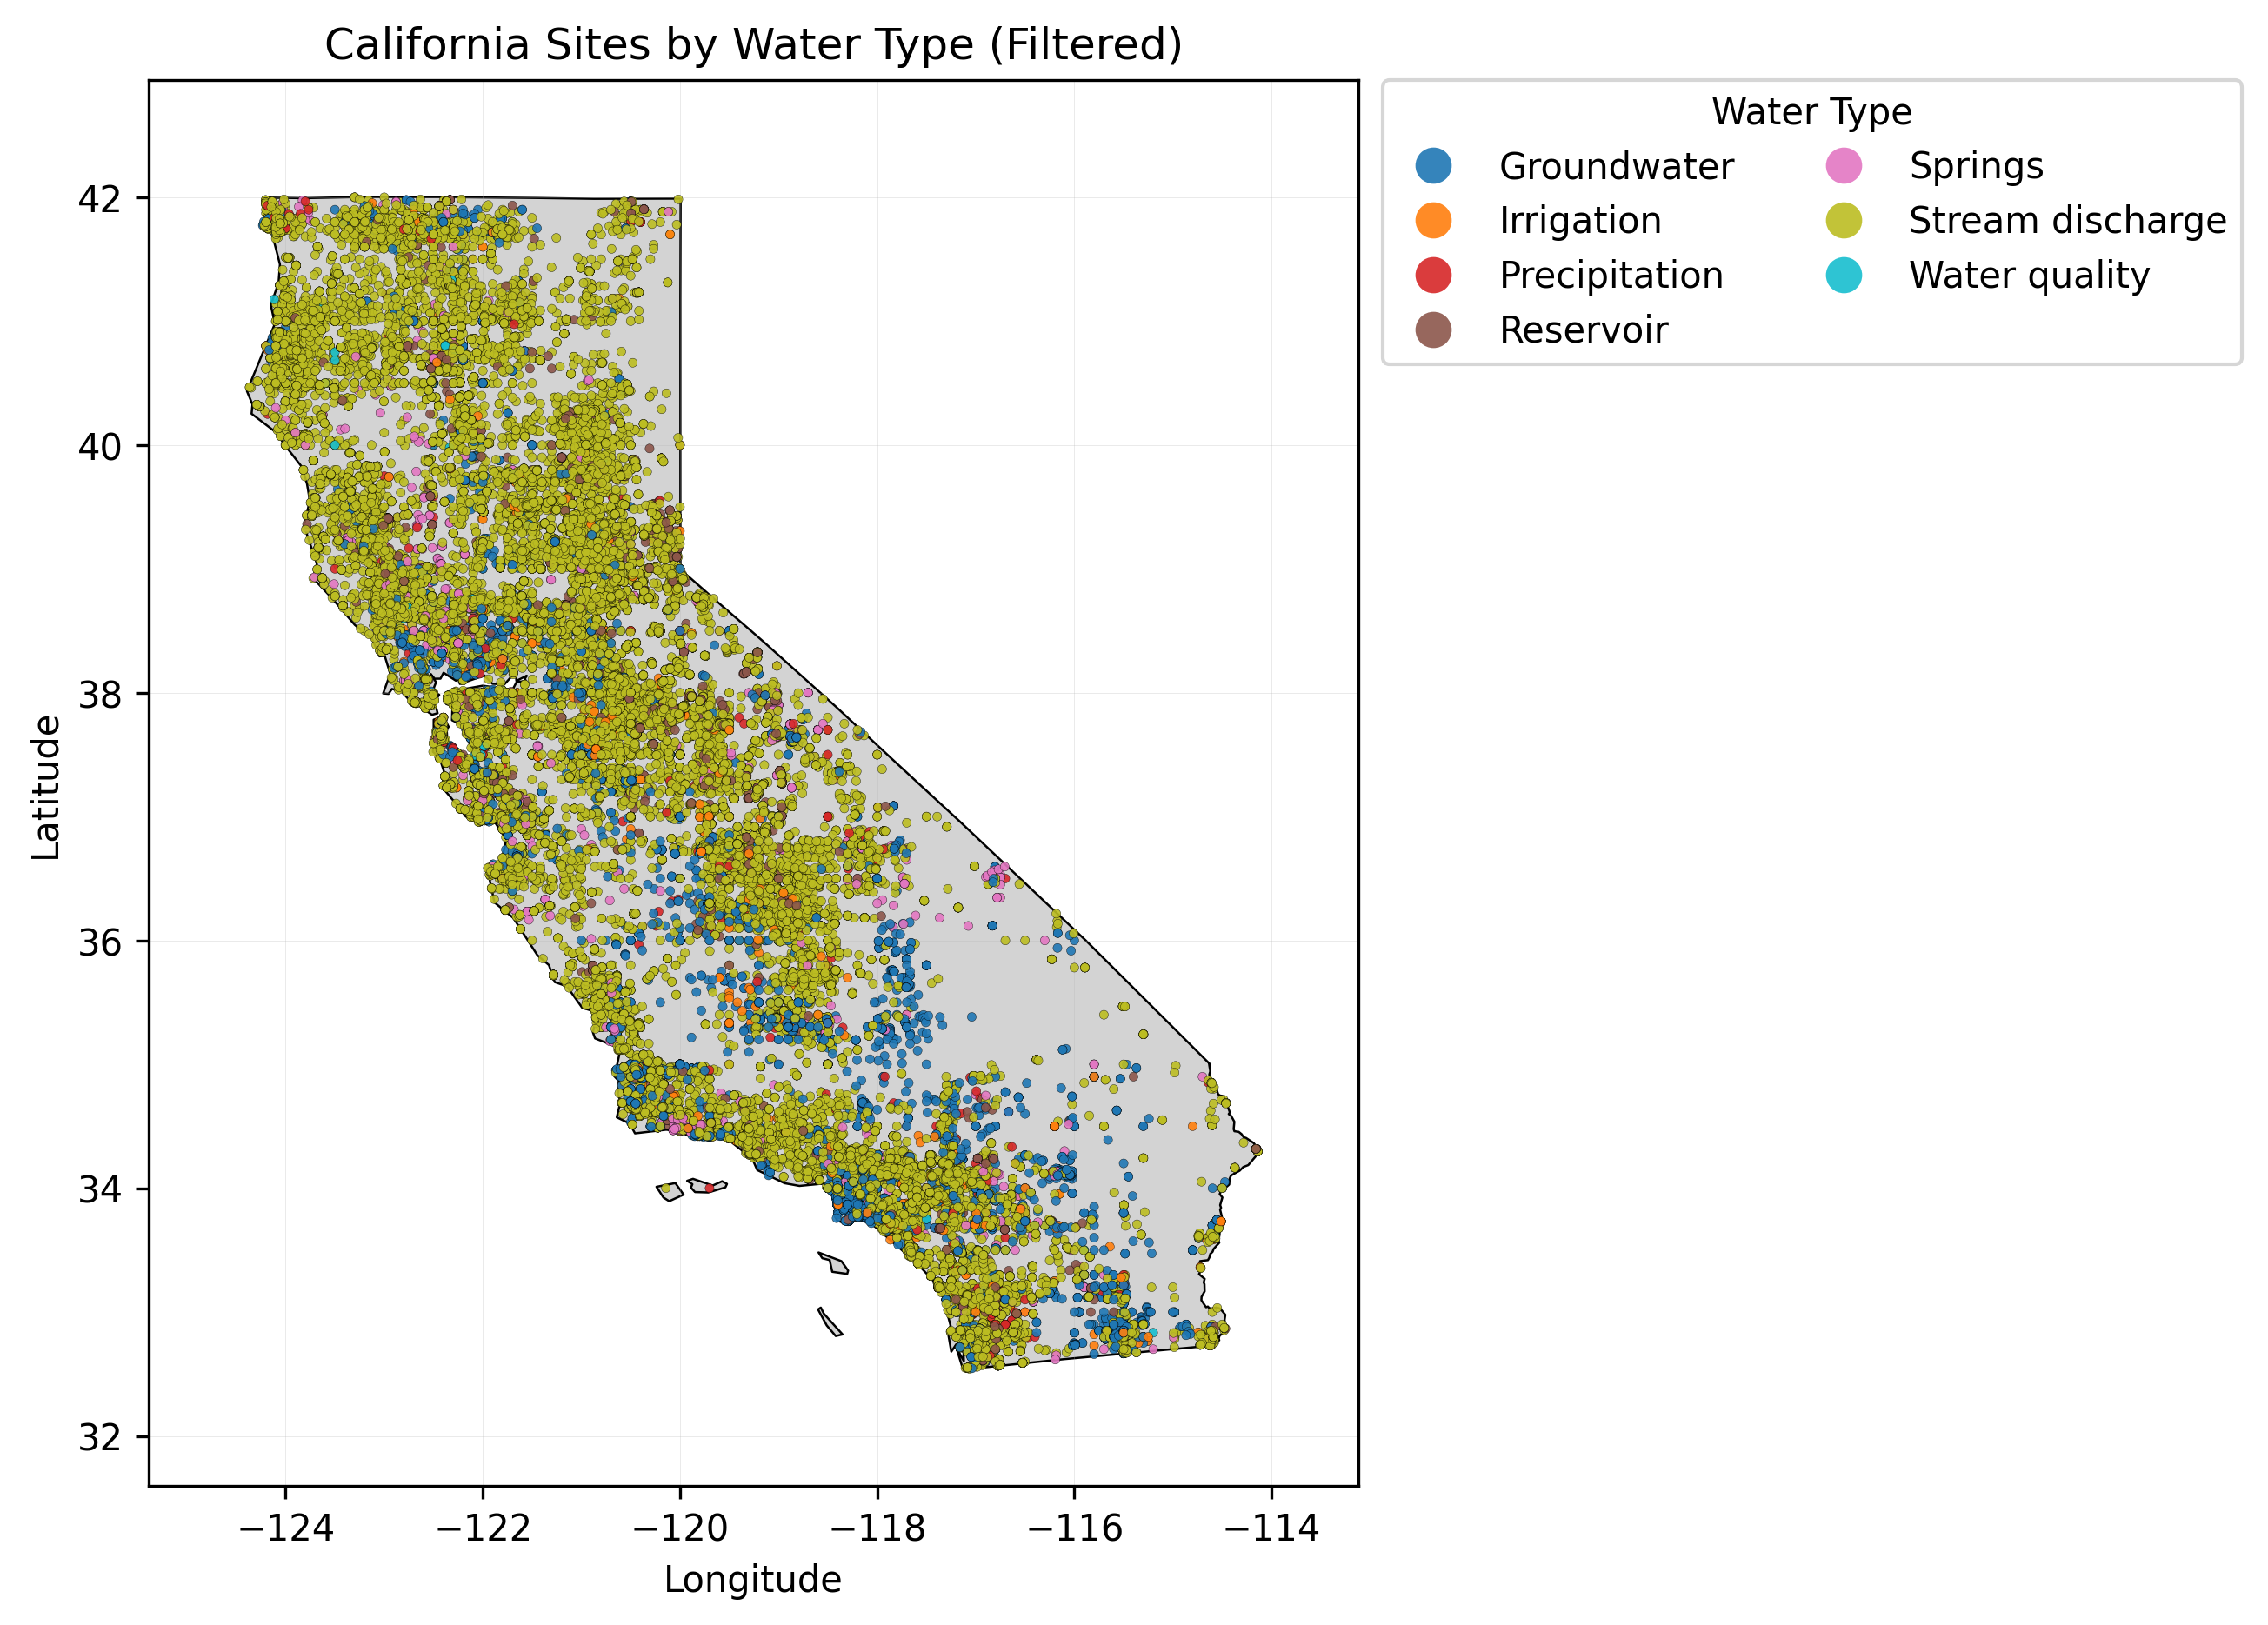

In [10]:
# ==== California-only map colored by water_type_clean (filtered) ====
import os
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

# Path to your CA shapefile
path_to_ca = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\ca_shapefile\ca_poly.shp"

# 1) Load California polygon (Shapely 2.x safe) and ensure WGS84
ca = gpd.read_file(path_to_ca)
if ca.empty:
    raise RuntimeError(f"No features found in {path_to_ca}")
if ca.crs is None:
    raise RuntimeError("California shapefile has no CRS defined. Please check the .prj file.")
if ca.crs.to_string().upper() not in ("EPSG:4326", "WGS84"):
    ca = ca.to_crs("EPSG:4326")
ca_poly = ca.union_all() if hasattr(ca, "union_all") else ca.unary_union

# 2) Points GeoDataFrame (WGS84)
gdf = gpd.GeoDataFrame(
    df_summary,
    geometry=gpd.points_from_xy(df_summary["lon_combined"], df_summary["lat_combined"]),
    crs="EPSG:4326"
)

# 3) Keep only points inside California
in_ca = gdf.within(ca_poly)
gdf_ca = gdf.loc[in_ca].copy()
if len(gdf_ca) == 0:
    raise RuntimeError("No points fall inside California based on your shapefile.")

# 4) Filter water_type_clean
cat_col = "water_type_clean"
if cat_col not in gdf_ca.columns:
    raise KeyError(f"Column '{cat_col}' not found in df_summary.")

gdf_ca[cat_col] = gdf_ca[cat_col].astype(str).replace({"nan": "Unknown"}).fillna("Unknown")

# Remove unwanted categories
drop_vals = {"not water related", "other"}
gdf_ca = gdf_ca[~gdf_ca[cat_col].str.lower().isin(drop_vals)].copy()

print("Categories retained:", gdf_ca[cat_col].unique())

# 5) Padded extent so nothing gets clipped
minx, miny, maxx, maxy = gdf_ca.total_bounds
pad_lon = max(0.5, (maxx - minx) * 0.10)
pad_lat = max(0.5, (maxy - miny) * 0.10)
xmin, ymin, xmax, ymax = (minx - pad_lon, miny - pad_lat, maxx + pad_lon, maxy + pad_lat)

# 6) Plot
fig, ax = plt.subplots(figsize=(9, 7), dpi=300)

# CA background polygon
gpd.GeoSeries([ca_poly], crs="EPSG:4326").plot(
    ax=ax, color="lightgray", edgecolor="black", linewidth=0.6, zorder=0
)

# Points colored by water_type_clean
gdf_ca.plot(
    ax=ax,
    column=cat_col,
    categorical=True,
    legend=True,
    legend_kwds={
        "title": "Water Type",
        "loc": "upper left",
        "bbox_to_anchor": (1.02, 1.0),
        "borderaxespad": 0.0,
        "ncol": 2,
    },
    markersize=6,
    alpha=0.9,
    edgecolor="k",
    linewidth=0.1,
    zorder=2,
)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title("California Sites by Water Type (Filtered)", fontsize=12)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linewidth=0.2, alpha=0.3)

# 7) Save
outdir = os.path.join("plots", run_id)
os.makedirs(outdir, exist_ok=True)
outfile = os.path.join(outdir, "CA_ONLY_by_water_type_filtered.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
print("Saved:", outfile)

plt.show()


In [11]:
# ==== One map per water_type_clean category (filtered) ====
import os
import matplotlib.pyplot as plt
import geopandas as gpd

# Path to your CA shapefile
path_to_ca = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\ca_shapefile\ca_poly.shp"

# 1) Load California polygon (Shapely 2.x safe)
ca = gpd.read_file(path_to_ca)
if ca.crs is None:
    raise RuntimeError("California shapefile has no CRS defined.")
if ca.crs.to_string().upper() not in ("EPSG:4326", "WGS84"):
    ca = ca.to_crs("EPSG:4326")
ca_poly = ca.union_all() if hasattr(ca, "union_all") else ca.unary_union

# 2) Build GeoDataFrame of points
gdf = gpd.GeoDataFrame(
    df_summary,
    geometry=gpd.points_from_xy(df_summary["lon_combined"], df_summary["lat_combined"]),
    crs="EPSG:4326"
)

# 3) Filter to CA points
gdf_ca = gdf.loc[gdf.within(ca_poly)].copy()

# 4) Filter water_type_clean
cat_col = "water_type_clean"
drop_vals = {"not water related", "other"}
gdf_ca[cat_col] = gdf_ca[cat_col].astype(str).replace({"nan": "Unknown"}).fillna("Unknown")
gdf_ca = gdf_ca[~gdf_ca[cat_col].str.lower().isin(drop_vals)].copy()

# 5) Compute padded extent once (so all maps have same scale)
minx, miny, maxx, maxy = gdf_ca.total_bounds
pad_lon = max(0.5, (maxx - minx) * 0.10)
pad_lat = max(0.5, (maxy - miny) * 0.10)
xmin, ymin, xmax, ymax = (minx - pad_lon, miny - pad_lat, maxx + pad_lon, maxy + pad_lat)

# 6) Output folder
outdir = os.path.join("plots", run_id, "by_water_type")
os.makedirs(outdir, exist_ok=True)

# 7) Loop through categories and plot each separately
categories = sorted(gdf_ca[cat_col].unique())
print(f"Making {len(categories)} maps...")

for cat in categories:
    sub = gdf_ca[gdf_ca[cat_col] == cat]
    
    fig, ax = plt.subplots(figsize=(8.5, 6.5), dpi=300)
    
    # Background CA polygon
    gpd.GeoSeries([ca_poly], crs="EPSG:4326").plot(
        ax=ax, color="lightgray", edgecolor="black", linewidth=0.6, zorder=0
    )
    
    # Plot category points
    sub.plot(
        ax=ax,
        color="C0",
        markersize=6,
        alpha=0.9,
        edgecolor="k",
        linewidth=0.1,
        zorder=2,
    )
    
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_title(f"California Sites: {cat}", fontsize=12)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, linewidth=0.2, alpha=0.3)
    
    # Save with safe filename
    safe_cat = "".join(c if c.isalnum() or c in ("_", "-") else "_" for c in cat)
    outfile = os.path.join(outdir, f"CA_sites_{safe_cat}.png")
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.close(fig)
    
    print("Saved:", outfile)


Making 7 maps...
Saved: plots\run_20250820_141313\by_water_type\CA_sites_Groundwater.png
Saved: plots\run_20250820_141313\by_water_type\CA_sites_Irrigation.png
Saved: plots\run_20250820_141313\by_water_type\CA_sites_Precipitation.png
Saved: plots\run_20250820_141313\by_water_type\CA_sites_Reservoir.png
Saved: plots\run_20250820_141313\by_water_type\CA_sites_Springs.png
Saved: plots\run_20250820_141313\by_water_type\CA_sites_Stream_discharge.png
Saved: plots\run_20250820_141313\by_water_type\CA_sites_Water_quality.png


## By decade

In [12]:
# ==== California-only maps by DECADE, colored by water_type_clean ====
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.cm import get_cmap

# --- CONFIG ---
path_to_ca = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\ca_shapefile\ca_poly.shp"
cat_col    = "water_type_clean"
drop_vals  = {"not water related", "other"}  # filter these out
panels_per_page = 6                           # e.g., 2 rows × 3 cols
ncols, nrows = 3, 2                           # layout for paginated panel figures
dpi = 300

# --- Load California polygon (Shapely 2.x safe) ---
ca = gpd.read_file(path_to_ca)
if ca.empty:
    raise RuntimeError(f"No features found in {path_to_ca}")
if ca.crs is None:
    raise RuntimeError("California shapefile has no CRS defined (.prj missing?).")
if ca.crs.to_string().upper() not in ("EPSG:4326", "WGS84"):
    ca = ca.to_crs("EPSG:4326")
ca_poly = ca.union_all() if hasattr(ca, "union_all") else ca.unary_union
ca_series = gpd.GeoSeries([ca_poly], crs="EPSG:4326")

# --- Build points GeoDataFrame ---
gdf = gpd.GeoDataFrame(
    df_summary,
    geometry=gpd.points_from_xy(df_summary["lon_combined"], df_summary["lat_combined"]),
    crs="EPSG:4326"
)

# --- Filter to California only ---
in_ca = gdf.within(ca_poly)
gdf_ca = gdf.loc[in_ca].copy()

# --- Filter categories ---
if cat_col not in gdf_ca.columns:
    raise KeyError(f"Column '{cat_col}' not found in df_summary.")
gdf_ca[cat_col] = gdf_ca[cat_col].astype(str).replace({"nan": "Unknown"}).fillna("Unknown")
gdf_ca = gdf_ca[~gdf_ca[cat_col].str.lower().isin(drop_vals)].copy()

# --- Guard: need decade column ---
if "decade" not in gdf_ca.columns:
    raise KeyError("Column 'decade' not found in df_summary.")

# --- Compute a single padded extent (so all panels match & nothing clipped) ---
minx, miny, maxx, maxy = gdf_ca.total_bounds
pad_lon = max(0.5, (maxx - minx) * 0.10)
pad_lat = max(0.5, (maxy - miny) * 0.10)
xmin, ymin, xmax, ymax = (minx - pad_lon, miny - pad_lat, maxx + pad_lon, maxy + pad_lat)

# --- Prepare categories & colors (colorblind-safe Tab20) ---
cats = sorted(gdf_ca[cat_col].unique())
cmap = get_cmap("tab20")
palette = {c: cmap(i % cmap.N) for i, c in enumerate(cats)}

# --- Output dirs ---
outdir = os.path.join("plots", run_id, "by_decade")
os.makedirs(outdir, exist_ok=True)

# --- 1) INDIVIDUAL PNG PER DECADE ---
decades = [d for d in sorted(gdf_ca["decade"].dropna().unique())]
print(f"Found {len(decades)} decades with data: {decades}")

for dec in decades:
    sub = gdf_ca[gdf_ca["decade"] == dec]
    if len(sub) == 0:
        continue

    fig, ax = plt.subplots(figsize=(8.5, 6.5), dpi=dpi)
    # CA background
    ca_series.plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.6, zorder=0)

    # Plot each category in consistent colors
    for c in cats:
        s = sub[sub[cat_col] == c]
        if len(s) == 0: 
            continue
        s.plot(ax=ax, color=palette[c], markersize=6, alpha=0.9, edgecolor="k", linewidth=0.1, zorder=2, label=c)

    ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
    ax.set_title(f"California Sites by Water Type — {dec}", fontsize=12)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.grid(True, linewidth=0.2, alpha=0.3)

    # Single legend outside
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, labels, title="Water Type", loc="upper left",
                  bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0, ncol=1, fontsize=8)

    safe_dec = str(dec).replace("/", "_")
    out_png = os.path.join(outdir, f"CA_by_water_type_{safe_dec}.png")
    plt.savefig(out_png, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", out_png)

# --- 2) PAGINATED PANEL FIGURES (e.g., 6 panels per page) ---
pages = math.ceil(len(decades) / panels_per_page)
print(f"Building {pages} panel page(s) with up to {panels_per_page} panels each...")

for p in range(pages):
    start = p * panels_per_page
    end = min((p + 1) * panels_per_page, len(decades))
    dec_slice = decades[start:end]
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 8), dpi=dpi)
    axes = np.array(axes).reshape(nrows, ncols)

    for idx, dec in enumerate(dec_slice):
        r, c = divmod(idx, ncols)
        ax = axes[r, c]

        sub = gdf_ca[gdf_ca["decade"] == dec]

        ca_series.plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.6, zorder=0)
        for cat in cats:
            s = sub[sub[cat_col] == cat]
            if len(s) == 0: 
                continue
            s.plot(ax=ax, color=palette[cat], markersize=5, alpha=0.9, edgecolor="k", linewidth=0.1, zorder=2)

        ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
        ax.set_title(f"{dec}", fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])  # cleaner panel look
        ax.set_xlabel(""); ax.set_ylabel("")
        ax.grid(True, linewidth=0.2, alpha=0.3)

    # Hide any unused axes on the last page
    for idx in range(len(dec_slice), nrows * ncols):
        r, c = divmod(idx, ncols)
        axes[r, c].axis("off")

    # Shared legend (right side)
    # Create dummy handles from palette/cats so legend includes all cats even if absent in this page
    from matplotlib.lines import Line2D
    handles = [Line2D([0],[0], marker='o', linestyle='',
                      markerfacecolor=palette[c], markeredgecolor='k', markersize=6, label=c)
               for c in cats]
    fig.legend(handles=handles, loc="center left", bbox_to_anchor=(1.01, 0.5),
               title="Water Type", frameon=False, fontsize=9)

    fig.suptitle("California Sites by Water Type — by Decade", fontsize=14, y=0.98)

    out_png = os.path.join(outdir, f"CA_by_water_type_panels_page_{p+1:02d}.png")
    plt.savefig(out_png, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    print("Saved panel page:", out_png)


C:\Users\aeliz\AppData\Local\Temp\ipykernel_26300\2947446900.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab20")


Found 16 decades with data: [np.int64(1820), np.int64(1840), np.int64(1850), np.int64(1860), np.int64(1870), np.int64(1880), np.int64(1890), np.int64(1900), np.int64(1910), np.int64(1920), np.int64(1930), np.int64(1940), np.int64(1950), np.int64(1960), np.int64(1970), np.int64(1980)]
Saved: plots\run_20250820_141313\by_decade\CA_by_water_type_1820.png
Saved: plots\run_20250820_141313\by_decade\CA_by_water_type_1840.png
Saved: plots\run_20250820_141313\by_decade\CA_by_water_type_1850.png
Saved: plots\run_20250820_141313\by_decade\CA_by_water_type_1860.png
Saved: plots\run_20250820_141313\by_decade\CA_by_water_type_1870.png
Saved: plots\run_20250820_141313\by_decade\CA_by_water_type_1880.png
Saved: plots\run_20250820_141313\by_decade\CA_by_water_type_1890.png
Saved: plots\run_20250820_141313\by_decade\CA_by_water_type_1900.png
Saved: plots\run_20250820_141313\by_decade\CA_by_water_type_1910.png
Saved: plots\run_20250820_141313\by_decade\CA_by_water_type_1920.png
Saved: plots\run_20250820

# Plot 1 — Water Category summary (grouped bar)

**Source table:** `summary_by_type`

**Spec:** Grouped horizontal bar plot with one row per water category and three bars per row representing `n_rows`, `n_pages`, and `n_docs`. Filters to the specified categories only. Exports 300 DPI PNG to `plots/<run_id>/watercat_summary.png`.


Saved figure to: plots\run_20250820_141313\watercat_summary.png


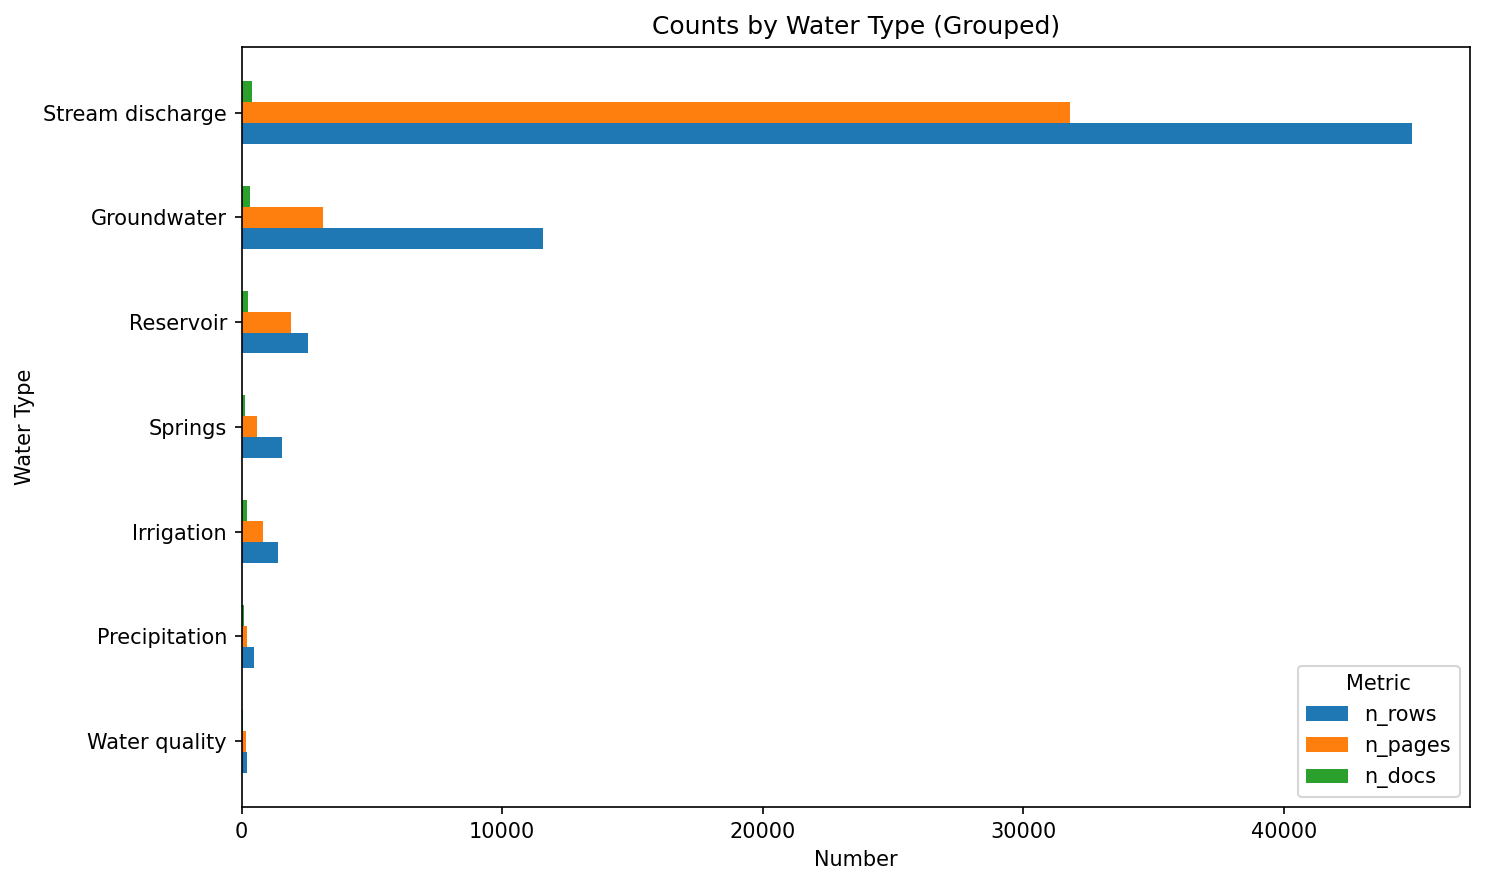

In [2]:

# --- Plot 1: grouped bar for summary_by_type ---
import os
import pandas as pd
import matplotlib.pyplot as plt
from artifacts_io import load_artifacts

# Load latest artifacts
tables, meta, run_dir = load_artifacts(out_dir="artifacts")

# Retrieve the source table
if "summary_by_type" not in tables:
    raise KeyError("The table 'summary_by_type' was not found in the saved artifacts. "
                   "Please ensure your analysis notebook saves it.")

df = tables["summary_by_type"].copy()

# Identify the category column (flexible naming)
cat_col_candidates = [c for c in df.columns if "water" in c.lower() and ("type" in c.lower() or "category" in c.lower())]
if not cat_col_candidates:
    # fallback: try a few common names
    for c in ["Water Category","Water Type","water_category","water_type","category","type"]:
        if c in df.columns:
            cat_col_candidates = [c]
            break

if not cat_col_candidates:
    raise KeyError("Could not identify the water category column in 'summary_by_type'. "
                   "Expected something like 'Water Category' or 'Water Type'.")

cat_col = cat_col_candidates[0]

# Ensure required metrics exist
metrics = ["n_rows","n_pages","n_docs"]
missing = [m for m in metrics if m not in df.columns]
if missing:
    raise KeyError(f"Missing expected columns in 'summary_by_type': {missing}. "
                   "Please ensure your analysis exported these metrics.")

# Filter to the requested categories (case-insensitive, robust to spacing)
wanted = ["groundwater","irrigation","stream discharge","precipitation","reservoir","springs","water quality"]

def norm(s):
    return str(s).strip().lower()

df["_norm_cat"] = df[cat_col].map(norm)
mask = df["_norm_cat"].isin([norm(x) for x in wanted])
df_f = df.loc[mask].copy()

# If some requested categories are absent, we can optionally warn
missing_cats = [w for w in wanted if norm(w) not in set(df_f["_norm_cat"])]
if missing_cats:
    print("Warning: These requested categories were not found in the table:", missing_cats)

# Sort categories by the largest metric to produce a nice order
df_f["max_metric"] = df_f[metrics].max(axis=1)
df_f = df_f.sort_values("max_metric", ascending=True)

# Prepare grouped horizontal bar
cats = df_f[cat_col].tolist()
import numpy as np
y = np.arange(len(cats))
bar_height = 0.2  # spacing for grouped bars

plt.figure(figsize=(10, 6), dpi=150)

for i, m in enumerate(metrics):
    plt.barh(y + (i - 1) * bar_height, df_f[m].values, height=bar_height, label=m)

plt.xlabel("Number")
plt.ylabel("Water Type")
plt.title("Counts by Water Type (Grouped)")
plt.yticks(y, cats)
plt.legend(title="Metric")
plt.tight_layout()

# Save export
run_id = os.path.basename(run_dir)
outdir = os.path.join("plots", run_id)
os.makedirs(outdir, exist_ok=True)
outfile = os.path.join(outdir, "watercat_summary.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
print("Saved figure to:", outfile)

plt.show()

# Optional: also export the filtered table for reference
exp_dir = os.path.join("exports", run_id)
os.makedirs(exp_dir, exist_ok=True)
df_f.drop(columns=["_norm_cat","max_metric"], errors="ignore").to_csv(os.path.join(exp_dir, "summary_by_type_filtered.csv"), index=False)


# Plot 2 — Counts by Water Type × Decade (stacked)

**Source table:** `summary_by_decade`  
**Spec:** Stacked bar chart of counts per decade (x-axis) with stacked segments by water type.  
- Keep decades **1860–1970** (inclusive).  
- Exclude categories: **'not water related'**, **'other'** (case-insensitive).  
- Save to `plots/<run_id>/watercat_by_decade.png` at **300 DPI**.


Saved figure to: plots\run_20250820_141313\watercat_by_decade.png


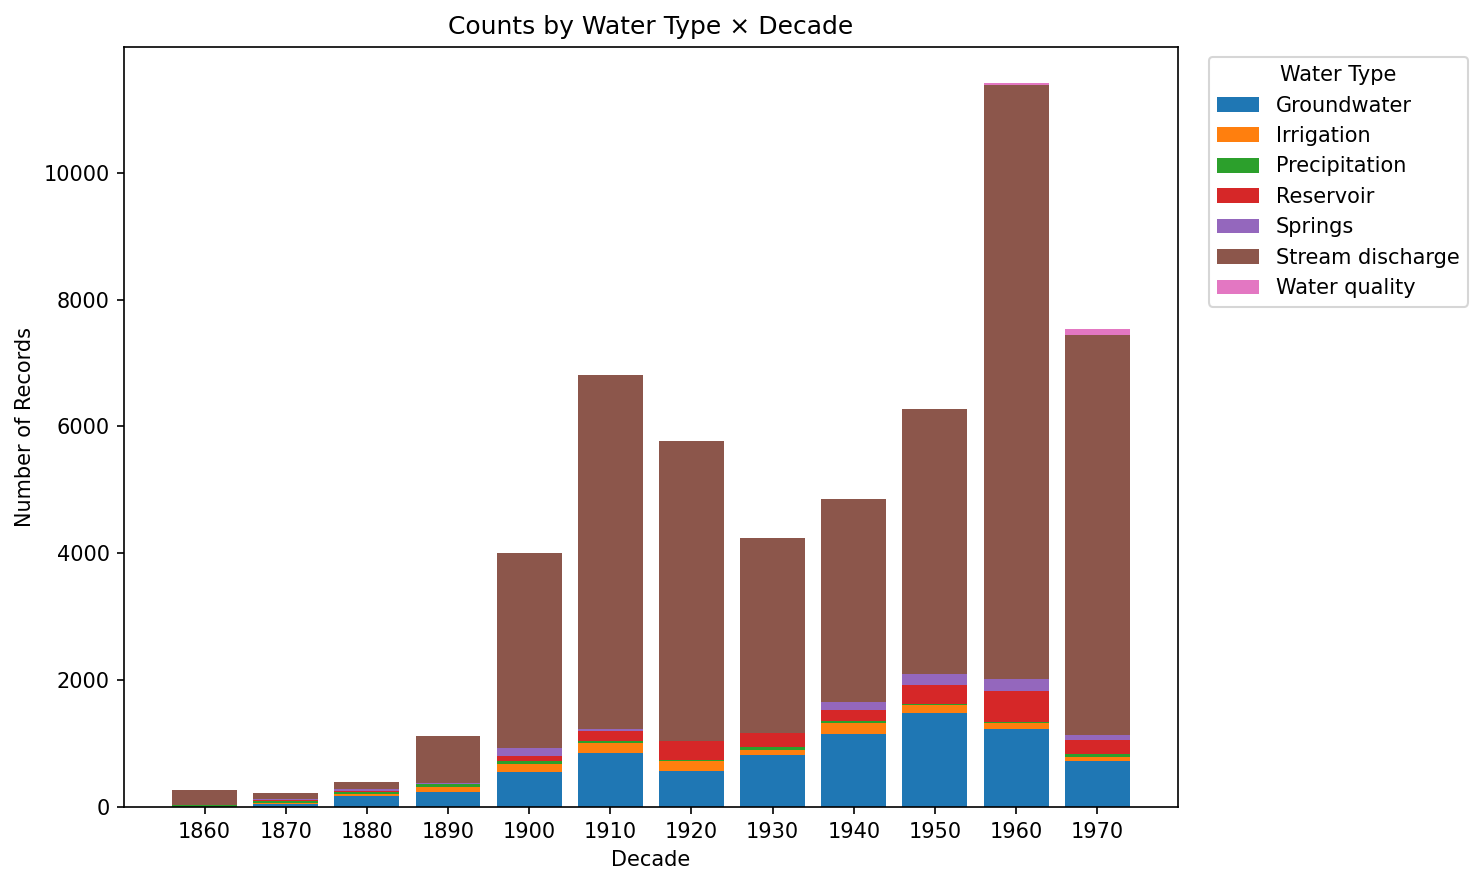

In [5]:

# --- Plot 2: Stacked bars by decade and water type ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from artifacts_io import load_artifacts

tables, meta, run_dir = load_artifacts(out_dir="artifacts")
if "summary_by_decade" not in tables:
    raise KeyError("The table 'summary_by_decade' was not found in artifacts.")

df = tables["summary_by_decade"].copy()

# Identify columns
decade_col = None
for c in df.columns:
    if "decade" in c.lower():
        decade_col = c
        break
if decade_col is None:
    raise KeyError("Could not detect a 'decade' column in summary_by_decade.")

# Try to find either (long-form) category+count or (wide-form) pivoted category columns
cat_col = None
count_col = None

# long-form search
name_candidates = ["water type","water category","water_type","water_category","type","category"]
for c in df.columns:
    if any(tok in c.lower() for tok in ["count","n_records","n","number","num","total"]) and c != decade_col:
        if pd.api.types.is_numeric_dtype(df[c]):
            count_col = c
            break

for c in df.columns:
    if any(n in c.lower() for n in name_candidates) and c != decade_col:
        cat_col = c
        break

if cat_col is not None and count_col is not None:
    # Already long-form
    long_df = df[[decade_col, cat_col, count_col]].copy()
    long_df.rename(columns={decade_col:"Decade", cat_col:"WaterType", count_col:"Count"}, inplace=True)
else:
    # Assume wide-form: one column per water category (numeric), plus the decade column
    numeric_cols = [c for c in df.columns if c != decade_col and pd.api.types.is_numeric_dtype(df[c])]
    if not numeric_cols:
        raise KeyError("Could not infer count columns in summary_by_decade. "
                       "Ensure it has either (Decade, WaterType, Count) long-form columns "
                       "or numeric category columns in wide-form.")
    wide = df[[decade_col] + numeric_cols].copy()
    long_df = wide.melt(id_vars=[decade_col], var_name="WaterType", value_name="Count")
    long_df.rename(columns={decade_col:"Decade"}, inplace=True)

# Normalize/clean values
def norm_cat(s):
    return str(s).strip()

long_df["WaterType"] = long_df["WaterType"].astype(str)
long_df["WaterType_norm"] = long_df["WaterType"].str.strip().str.lower()

# Filter decades 1860-1970 inclusive
def parse_dec(d):
    try:
        return int(str(d)[:4])  # if like "1860s", take first 4 chars
    except Exception:
        try:
            return int(float(d))
        except Exception:
            return np.nan

long_df["DecadeNum"] = long_df["Decade"].apply(parse_dec)
long_df = long_df.dropna(subset=["DecadeNum"])
long_df = long_df[(long_df["DecadeNum"] >= 1860) & (long_df["DecadeNum"] <= 1970)].copy()

# Exclude categories
exclude = {"not water related","other"}
long_df = long_df[~long_df["WaterType_norm"].isin(exclude)].copy()

# Pivot for stacked plotting
pvt = long_df.pivot_table(index="DecadeNum", columns="WaterType", values="Count", aggfunc="sum", fill_value=0)
pvt = pvt.sort_index()

plt.figure(figsize=(10,6), dpi=150)
bottom = np.zeros(len(pvt))
x = np.arange(len(pvt.index))

# Plot each category with default matplotlib colors
for col in pvt.columns:
    vals = pvt[col].values
    plt.bar(pvt.index.astype(str), vals,
            bottom=bottom, label=col)
    bottom += vals

plt.xlabel("Decade")
plt.ylabel("Number of Records")
plt.title("Counts by Water Type × Decade")
plt.legend(title="Water Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

# Save
run_id = os.path.basename(run_dir)
outdir = os.path.join("plots", run_id)
os.makedirs(outdir, exist_ok=True)
outfile = os.path.join(outdir, "watercat_by_decade.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
print("Saved figure to:", outfile)

plt.show()



# Export the filtered long-form used to build the plot (for reproducibility)
exp_dir = os.path.join("exports", run_id)
os.makedirs(exp_dir, exist_ok=True)
long_df[["DecadeNum","WaterType","Count"]].to_csv(os.path.join(exp_dir, "summary_by_decade_filtered_long.csv"), index=False)
